In [42]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from upsetplot import UpSet, from_indicators, plot as uplot

In [43]:
import warnings
warnings.filterwarnings('ignore')

In [44]:
plt.rcParams['pdf.fonttype'] = 42

In [3]:
!cp ../src/metadata/MB_sex_cohort.csv metadata

In [6]:
!cp ../data/combined_meta.csv metadata/

In [23]:
!cp /home/dfilipov/PROJECTS/cohorts/SJMB03/data/landscape_data/landscape_metadata_dna_seq.csv metadata/Northcott_2017_genomics.csv

In [26]:
!cp /home/dfilipov/PROJECTS/cohorts/XY_bias/FIGURES/DATA/microarray/microarray_metadata.csv metadata/Cavalli_Northcott_RNA_microarray.csv

In [10]:
# TODO
[DONE] combined_meta.csv >> genomics_combined_metadata.csv
    within genomics_combined_metadata fix SHH subtypes (alpha --> SHH-3, etc.)

landscape_metadata_dna_seq.csv >> Northcott_2017_genomics.csv

microarray_metadata.csv >> Cavalli_Northcott_RNA_microarray.csv

In [45]:
# at least methylation (bulk of the cohort)
sex_cohort = pd.read_csv('metadata/MB_sex_cohort.csv', index_col=0).query('~idat_type.isna()')
sex_cohort['methylation'] = True
sex_cohort['transcriptomics'] = False

# methylation + RNA-seq
sex_cohort.loc[sex_cohort.query('~RNA_ID.isna()').index, 'transcriptomics'] = True

In [46]:
# genomics w/ methylation
genomics_combined_metadata = pd.read_csv('metadata/genomics_combined_metadata.csv', index_col=0)
genomics_combined_metadata['genomics'] = True

In [47]:
# Northcott 2017 (genomics only)
nortchott_2017_metadata = pd.read_csv('metadata/Northcott_2017_genomics.csv')

nortchott_2017_only_genomics = nortchott_2017_metadata.query('COHORT != "SJMB_WGS" & METH_450K.isna()').copy()

nortchott_2017_only_genomics['genomics'] = True
nortchott_2017_only_genomics['methylation'] = False

In [48]:
# combined RNA microarray (Cavalli + Northcott)
marray_md = pd.read_csv('metadata/Cavalli_Northcott_RNA_microarray.csv')

marray_md['genomics'] = False
marray_md['methylation'] = True
marray_md['transcriptomics'] = True

In [ ]:
up_data = pd.concat([
    sex_cohort.merge(
        genomics_combined_metadata[['idat', 'genomics']], 
        left_index=True, 
        right_on='idat', 
        how='left'
    )[['idat', 'genomics', 'methylation', 'transcriptomics']].merge(
        marray_md[['idat', 'transcriptomics']], 
        left_on='idat', 
        right_on='idat', 
        how='left'
    ),
    nortchott_2017_only_genomics[['genomics', 'methylation']]
]).fillna(False)

up_data['transcriptomics'] = up_data['transcriptomics_x'] | up_data['transcriptomics_y']
up_data = up_data.drop(columns=['transcriptomics_x', 'transcriptomics_y'])

up_data = up_data.reset_index(drop=True).reset_index().rename(columns={'index': 'patient_id'})

In [61]:
def plot_upset(df):
    """
    Creates the upset plot representing the avaliable data types
    """    
    upset_data = from_indicators(
        indicators=["methylation", "genomics", "transcriptomics"],
        data=df.set_index("patient_id").astype(bool)
    ).copy()
    
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({
        "font.size": 12,
        "axes.labelsize": 12,
        "axes.titlesize": 14,
        "figure.dpi": 300,
        "axes.linewidth": 1.2,
        "axes.edgecolor": "black",
    })
    
    
    up = UpSet(
        upset_data,
        subset_size='count',
        sort_by='degree',
        facecolor='black',
        show_counts=False,
        intersection_plot_elements=10,
        element_size=35,
    )
    
    
    fig = plt.figure(figsize=(8, 4))
    
    uplot(upset_data, element_size=None, fig=fig)
    
    
    
    ax_bars = [a for a in fig.axes if a.get_ylabel() == 'Intersection size'][0]    
    for patch in ax_bars.patches:
        height = patch.get_height()
        if height > 0:
            ax_bars.text(
                patch.get_x() + patch.get_width() / 2,
                height + 0.2,
                f"{int(height)}",
                ha="center", va="bottom",
                fontsize=10, fontweight="bold", color="black"
            )
    ax_bars.set_ylabel('Patient count')
    
    plt.suptitle(f"Primary MB cohort (N={len(df)})",
                 fontsize=14, fontweight="bold")
    

    plt.subplots_adjust(top=0.85, left=0.15, right=0.95, bottom=0.1)

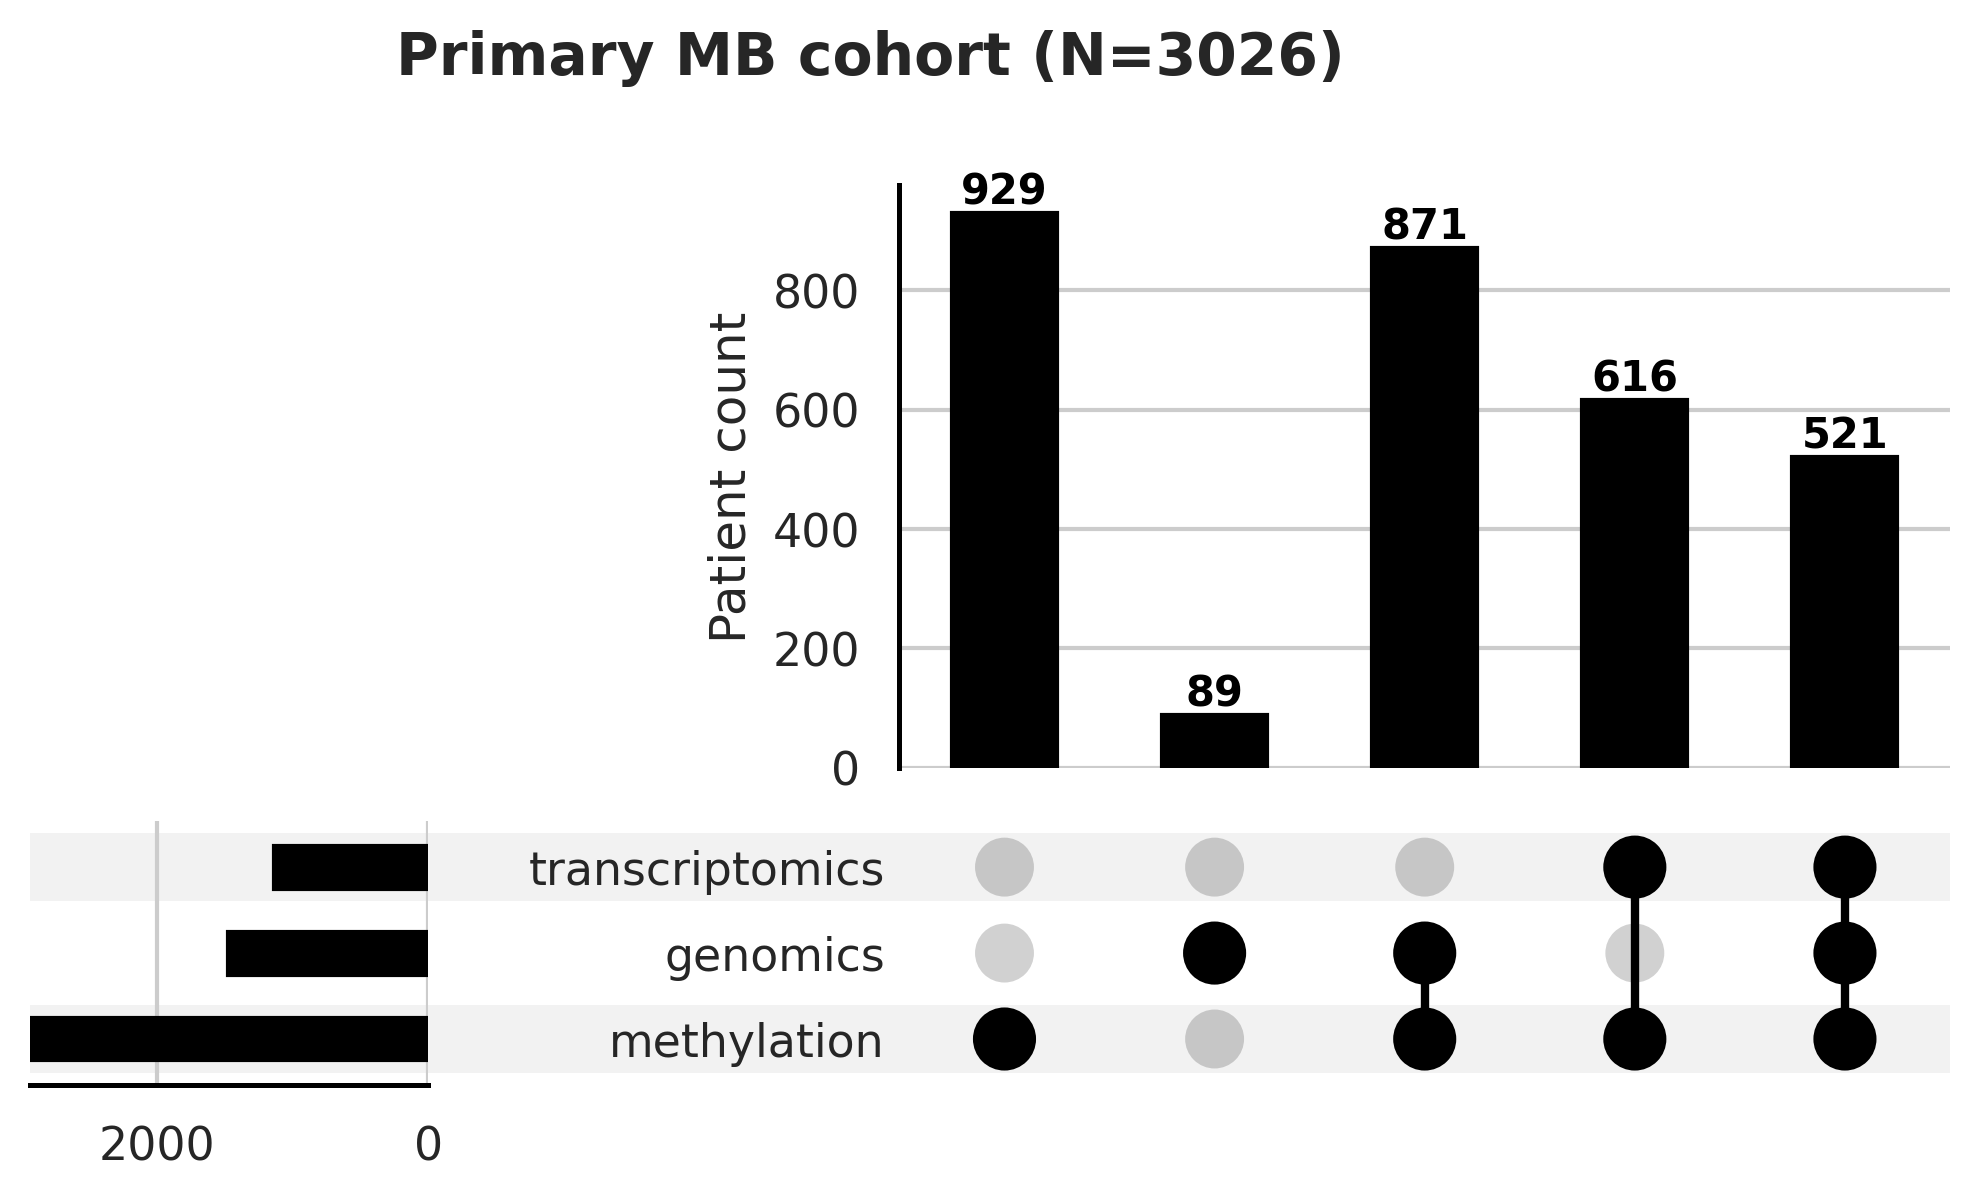

In [63]:
plot_upset(up_data)
plt.savefig('Figures/Fig_1B_upset_plot.pdf', dpi=300)
plt.show()